# Multi-Touch Attribution: Last-Click vs. Markov Chains vs. Shapley (with a Ground-Truth Check)

> **Note:** personal practice project. The journey data is **simulated** (see `data/generate_data.py`).
> Methodology is real; figures are not from a live client.

**Business question:** most accounts still report conversions by *last click*. In my retention project I flagged that
last-touch view can make awareness channels such as Programmatic look weak while Brand Search looks great.
This project tests that claim properly:

> **If we credit conversions with different attribution models, how much do the answers differ,
> which model is closest to the truth, and what would that change in the budget?**

**Why simulated data is an advantage here:** in real life the true incremental effect of a channel is never observable.
Because I generated the journeys, I kept the hidden causal effect of every touch, so each model can be **graded against ground truth**.
(In a real account this role is played by incrementality tests: geo experiments and holdouts.)

**Workflow:** clean tracking data -> build customer journeys -> rule-based models -> data-driven models
(Markov chain with bootstrap confidence intervals, Shapley values) -> validate against ground truth -> ROAS and budget implications.

## Key findings (simulated data: 60,000 users, 2,669 conversions)

- **Journeys are multi-touch.** 76% of converters had 2+ touchpoints, 71% were touched by 2+ different channels, and the median time from first touch to conversion was 4.7 days.
- **Channels play different roles.** Programmatic is the top *assister* (it appears earlier in a converting journey 2.1x for every time it closes one), while Google Search (Brand) is mostly a *closer* (89 first touches vs. 567 last touches).
- **The model you pick changes the answer.** Brand Search gets between 3% (first-click) and 21% (last-click) of credit; Programmatic gets between 12% (last-click) and 23% (first-click).
- **No model matches the ground truth.** Mean absolute error is 3.9 to 5.2 share points for every model except first-click (7.0). Rankings are mostly preserved (Spearman >= 0.94, except last-click 0.77 and first-click 0.54), but magnitudes are off by up to 13 points: Generic Search truly drives 34% of incremental conversions, while every model gives it 21-24%.
- **More sophisticated is not automatically more accurate.** In this simulation the Markov chain (5.2 pts MAE) did not beat the simple position-based model (3.9 pts). Its 95% bootstrap intervals are very narrow yet exclude the true share for all six channels: *statistical precision is not accuracy*.
- **About 25% of conversions (659) would have happened with no marketing touch at all.** Every attribution model hands that credit to channels anyway; only experiments can separate it.
- **Budget implication:** last-click ROAS overstates Brand Search by ~2.8x (21.6x vs. 7.7x true incremental ROAS) and Programmatic by ~1.8x (1.8x vs. 1.0x). Programmatic receives 41% of spend but ~10% of true incremental credit. Generic Search is the one channel where last-click ROAS is almost exactly right (7.5x vs. 7.5x).

> These conclusions are consequences of the lift parameters I assumed when simulating the data. The point of the project is the **method**: how to compare attribution models, quantify their uncertainty, and grade them against a known truth.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from itertools import combinations
from math import factorial
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

DATA, IMG, REP = Path("../data"), Path("../images"), Path("../reports")
IMG.mkdir(exist_ok=True); REP.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", rc={"axes.grid.axis": "y"})
PALETTE = {"primary": "#1f4e79", "accent": "#e07b39", "muted": "#9aa5b1", "good": "#2e8b57", "bad": "#c0392b"}
pd.options.display.float_format = "{:,.2f}".format

CH = ["Programmatic", "Meta Ads", "Google Search (Generic)", "Google Search (Brand)", "Email", "Organic / SEO"]
SHORT = {"Programmatic": "Programmatic", "Meta Ads": "Meta", "Google Search (Generic)": "Search\n(Generic)",
         "Google Search (Brand)": "Search\n(Brand)", "Email": "Email", "Organic / SEO": "Organic"}

## 1. Data cleaning

In [2]:
touch_raw = pd.read_csv(DATA / "touchpoints.csv", parse_dates=["touch_time"])
conv = pd.read_csv(DATA / "conversions.csv", parse_dates=["conversion_time"])
spend = pd.read_csv(DATA / "channel_spend.csv")

log = {"Raw touchpoints": len(touch_raw)}
touch = touch_raw.copy()

# 1) standardise channel names (casing, whitespace, aliases)
CANON = {"programmatic": "Programmatic", "meta ads": "Meta Ads", "google search (generic)": "Google Search (Generic)",
         "google search (brand)": "Google Search (Brand)", "email": "Email", "e-mail": "Email", "organic/seo": "Organic / SEO"}
key = touch["channel"].str.lower().str.replace(r"\s*/\s*", "/", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
touch["channel"] = key.map(CANON)
assert touch["channel"].notna().all(), "unmapped channel name"
log["Rows with a non-standard channel name (fixed)"] = int((touch_raw["channel"] != touch["channel"]).sum())

# 2) exact duplicates (tracking fired twice)
before = len(touch)
touch = touch.drop_duplicates(["user_id", "touch_time", "channel"])
log["Duplicate touchpoints removed"] = before - len(touch)

# 3) no credit for touches AFTER the conversion, and a 30-day lookback window before it
touch = touch.merge(conv, on="user_id", how="left")
after = touch["conversion_time"].notna() & (touch["touch_time"] > touch["conversion_time"])
log["Post-conversion touchpoints removed"] = int(after.sum())
touch = touch[~after]
too_old = touch["conversion_time"].notna() & (touch["touch_time"] < touch["conversion_time"] - pd.Timedelta(days=30))
log["Touchpoints outside 30-day lookback removed"] = int(too_old.sum())
touch = touch[~too_old].sort_values(["user_id", "touch_time"]).reset_index(drop=True)

log["Clean touchpoints"] = len(touch)
log["Users"] = touch["user_id"].nunique()
log["Conversions"] = conv["user_id"].nunique()
pd.Series(log, name="count").to_frame()

,count
Raw touchpoints,136800
Rows with a non-standard channel name (fixed),2720
Duplicate touchpoints removed,681
Post-conversion touchpoints removed,133
Touchpoints outside 30-day lookback removed,28
Clean touchpoints,135958
Users,60000
Conversions,2669


## 2. Building customer journeys

In [3]:
j = touch.groupby("user_id").agg(path=("channel", list), n_touches=("channel", "size"),
                                 first_touch=("touch_time", "min"))
j = j.join(conv.set_index("user_id"))
j["converted"] = j["conversion_time"].notna()
j["revenue"] = j["revenue"].fillna(0.0)
j["path_str"] = j["path"].str.join(" > ")
j["days_to_convert"] = (j["conversion_time"] - j["first_touch"]).dt.total_seconds() / 86400

N, NC = len(j), int(j.converted.sum())
cj = j[j.converted]
pd.Series({
    "Users with >=1 tracked touch": f"{N:,}",
    "Conversions": f"{NC:,}",
    "Conversion rate": f"{NC / N:.2%}",
    "Revenue": f"${j.revenue.sum():,.0f}",
    "Average order value": f"${cj.revenue.mean():,.2f}",
    "Avg touches per user (converters / non-converters)": f"{cj.n_touches.mean():.2f} / {j[~j.converted].n_touches.mean():.2f}",
    "Converters with a single touch": f"{(cj.n_touches == 1).mean():.1%}",
    "Converters touched by 2+ different channels": f"{cj.path.apply(lambda p: len(set(p)) > 1).mean():.1%}",
    "Median days from first touch to conversion": f"{cj.days_to_convert.median():.1f}",
}, name="Journey KPIs").to_frame()

,Journey KPIs
Users with >=1 tracked touch,"60,000"
Conversions,"2,669"
Conversion rate,4.45%
Revenue,"$185,685"
Average order value,$69.57
Avg touches per user (converters / non-converters),2.81 / 2.24
Converters with a single touch,23.7%
Converters touched by 2+ different channels,70.6%
Median days from first touch to conversion,4.7


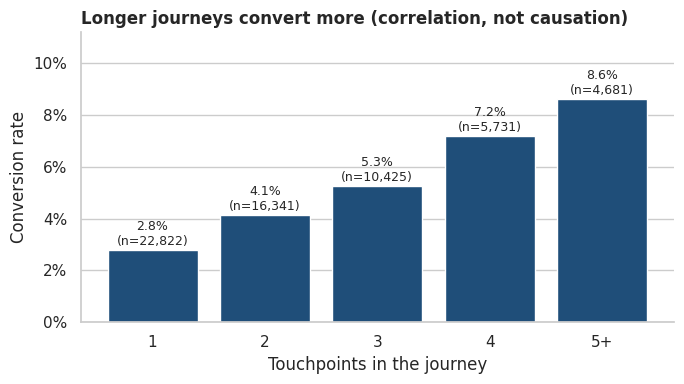

,users,conversions,conv_rate
path_str,,,
Meta Ads,6251,188,3.0%
Google Search (Generic),3980,176,4.4%
Organic / SEO,4779,130,2.7%
Programmatic,6562,111,1.7%
Programmatic > Google Search (Brand),1506,53,3.5%
Programmatic > Google Search (Generic),932,50,5.4%
Meta Ads > Google Search (Brand),1423,47,3.3%
Meta Ads > Google Search (Generic),844,46,5.5%
Organic / SEO > Google Search (Generic),702,43,6.1%


In [4]:
# Conversion rate by path length, and top converting paths
bins = j["n_touches"].clip(upper=5)
by_len = j.groupby(bins).agg(users=("converted", "size"), conv_rate=("converted", "mean"))
by_len.index = [str(i) if i < 5 else "5+" for i in by_len.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_len.index, by_len["conv_rate"], color=PALETTE["primary"])
for i, (r, u) in enumerate(zip(by_len["conv_rate"], by_len["users"])):
    ax.text(i, r + 0.002, f"{r:.1%}\n(n={u:,})", ha="center", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_ylim(0, by_len.conv_rate.max() * 1.3)
ax.set_xlabel("Touchpoints in the journey"); ax.set_ylabel("Conversion rate")
ax.set_title("Longer journeys convert more (correlation, not causation)", fontweight="bold", loc="left")
sns.despine(); plt.tight_layout(); plt.savefig(IMG / "01_conversion_by_path_length.png", dpi=150); plt.show()

top = (j.groupby("path_str").agg(users=("converted", "size"), conversions=("converted", "sum"))
         .assign(conv_rate=lambda d: d.conversions / d.users)
         .sort_values("conversions", ascending=False).head(10))
top["conv_rate"] = top["conv_rate"].map("{:.1%}".format)
top

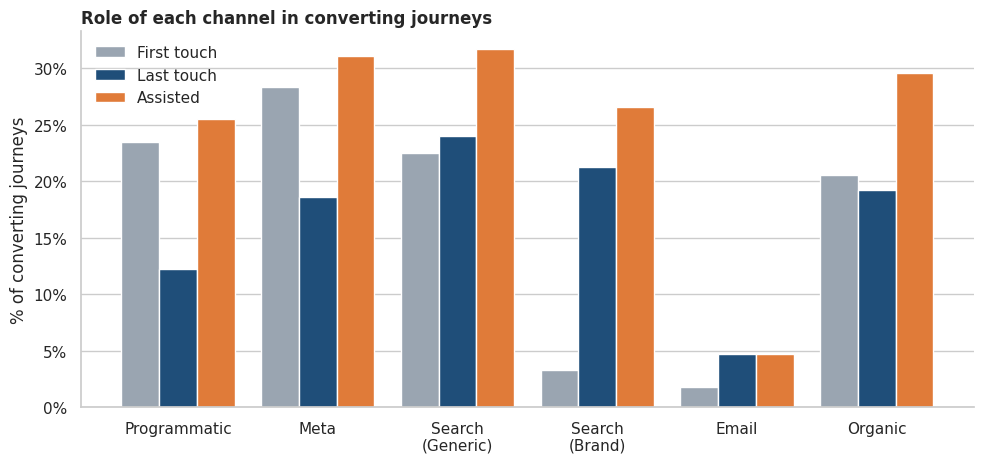

,first_touch,last_touch,assisted,assist_ratio
Programmatic,627,326,681,2.09
Meta Ads,757,497,828,1.67
Google Search (Generic),600,640,845,1.32
Google Search (Brand),89,567,708,1.25
Email,47,127,126,0.99
Organic / SEO,549,512,789,1.54


In [5]:
# First-touch / last-touch / assist profile of each channel among converting journeys
prof = pd.DataFrame(index=CH)
prof["first_touch"] = cj["path"].str[0].value_counts().reindex(CH).fillna(0)
prof["last_touch"] = cj["path"].str[-1].value_counts().reindex(CH).fillna(0)
prof["assisted"] = [cj["path"].apply(lambda p, c=c: c in p[:-1]).sum() for c in CH]
prof["assist_ratio"] = prof["assisted"] / prof["last_touch"]

pct = prof[["first_touch", "last_touch", "assisted"]] / NC
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(CH)); w = 0.27
for k, (col, color) in enumerate(zip(["first_touch", "last_touch", "assisted"], [PALETTE["muted"], PALETTE["primary"], PALETTE["accent"]])):
    ax.bar(x + (k - 1) * w, pct[col], w, label=col.replace("_", " ").capitalize(), color=color)
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CH])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("% of converting journeys")
ax.set_title("Role of each channel in converting journeys", fontweight="bold", loc="left")
ax.legend(frameon=False); sns.despine(); plt.tight_layout()
plt.savefig(IMG / "02_channel_roles.png", dpi=150); plt.show()

out = prof.copy(); out[["first_touch", "last_touch", "assisted"]] = out[["first_touch", "last_touch", "assisted"]].astype(int)
out

## 3. Rule-based attribution models

| Model | Rule |
|---|---|
| Last-click | 100% to the final touch |
| First-click | 100% to the first touch |
| Linear | equal credit to every touch |
| Time-decay | credit halves every 7 days before the conversion |
| Position-based | 40% first, 40% last, 20% shared by the middle touches |

In [6]:
ct = touch[touch["conversion_time"].notna()].copy()                    # converting journeys only (conversion_time and revenue already merged)
ct = ct.sort_values(["user_id", "touch_time"]).reset_index(drop=True)
g = ct.groupby("user_id")
ct["pos"] = g.cumcount()
ct["n"] = g["channel"].transform("size")
ct["days_before"] = (ct["conversion_time"] - ct["touch_time"]).dt.total_seconds() / 86400

w = pd.DataFrame(index=ct.index)
w["Last-click"] = (ct.pos == ct.n - 1).astype(float)
w["First-click"] = (ct.pos == 0).astype(float)
w["Linear"] = 1.0 / ct.n
raw = 0.5 ** (ct.days_before / 7.0)
w["Time-decay"] = raw / raw.groupby(ct["user_id"]).transform("sum")
mid = 0.2 / (ct.n - 2).clip(lower=1)
w["Position-based"] = np.where(ct.n == 1, 1.0, np.where(ct.n == 2, 0.5,
                      np.where((ct.pos == 0) | (ct.pos == ct.n - 1), 0.4, mid)))

RULE_MODELS = list(w.columns)
conv_credit = pd.DataFrame({m: (w[m]).groupby(ct["channel"]).sum() for m in RULE_MODELS}).reindex(CH)
rev_credit = pd.DataFrame({m: (w[m] * ct["revenue"]).groupby(ct["channel"]).sum() for m in RULE_MODELS}).reindex(CH)

assert np.allclose(conv_credit.sum(), NC), "each model must distribute exactly the observed conversions"
conv_credit

,Last-click,First-click,Linear,Time-decay,Position-based
channel,,,,,
Programmatic,326.00,627.00,425.32,400.71,455.73
Meta Ads,497.00,757.00,586.21,563.45,609.15
Google Search (Generic),640.00,600.00,631.18,630.92,624.09
Google Search (Brand),567.00,89.00,415.01,452.88,365.74
Email,127.00,47.00,86.38,93.10,86.63
Organic / SEO,512.00,549.00,524.91,527.95,527.65


## 4. Markov chain attribution

Journeys are modelled as a first-order Markov chain: `START -> channel -> ... -> CONVERSION or NULL (no conversion)`.
A channel's **removal effect** is the relative drop in overall conversion probability when every transition into that channel
is redirected to NULL (the user never gets past it). Credit is proportional to removal effects.
Unlike rule-based models, this uses **non-converting journeys** too, so it can tell a channel that appears in many winning paths
from one that merely appears in many paths.

To quantify uncertainty I **bootstrap** the users (500 resamples) and report 95% intervals.

In [7]:
STATES = ["START"] + CH + ["CONV", "NULL"]
S = {s: i for i, s in enumerate(STATES)}
nS = len(STATES)

# Unique (path, converted) combinations and their transition-count contribution (fast bootstrap)
pc = j.groupby(["path_str", "converted"]).agg(n=("converted", "size"), path=("path", "first")).reset_index()
contrib = np.zeros((len(pc), nS, nS))
for k, row in pc.iterrows():
    seq = ["START"] + row["path"] + ["CONV" if row["converted"] else "NULL"]
    for a, b in zip(seq[:-1], seq[1:]):
        contrib[k, S[a], S[b]] += 1
counts = pc["n"].to_numpy().astype(float)
print(f"{len(pc):,} unique (path, outcome) combinations from {N:,} users")

def conv_prob(P, removed=None):
    P = P.copy()
    if removed is not None:
        i = S[removed]
        P[:, S["NULL"]] += P[:, i]; P[:, i] = 0.0                      # transitions into the channel lead nowhere
    tr = [S["START"]] + [S[c] for c in CH]
    Q = P[np.ix_(tr, tr)]; R = P[np.ix_(tr, [S["CONV"], S["NULL"]])]
    B = np.linalg.solve(np.eye(len(tr)) - Q, R)
    return B[0, 0]

def markov_shares(weights):
    M = np.tensordot(weights, contrib, axes=1)
    P = M / M.sum(1, keepdims=True).clip(min=1e-12)
    base = conv_prob(P)
    re = np.array([1 - conv_prob(P, c) / base for c in CH])
    return re / re.sum(), re, P

markov_share, removal_effect, P_full = markov_shares(counts)

# sanity checks: rows are probability distributions, and the chain reproduces the observed conversion rate exactly
assert np.allclose(P_full[:-2].sum(1), 1.0)
assert np.isclose(conv_prob(P_full), NC / N), "absorption probability must equal the observed conversion rate"
print(f"Model conversion probability {conv_prob(P_full):.4%} = observed conversion rate {NC / N:.4%}")
pd.DataFrame({"removal_effect": removal_effect, "markov_share": markov_share}, index=CH)

5,272 unique (path, outcome) combinations from 60,000 users
Model conversion probability 4.4483% = observed conversion rate 4.4483%


,removal_effect,markov_share
Programmatic,0.32,0.17
Meta Ads,0.39,0.21
Google Search (Generic),0.38,0.21
Google Search (Brand),0.34,0.18
Email,0.07,0.04
Organic / SEO,0.36,0.19


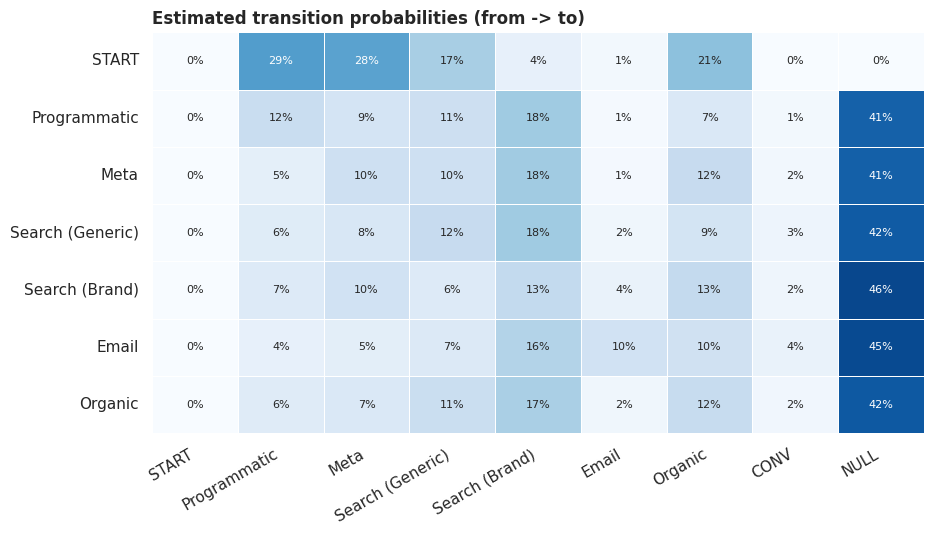

In [8]:
# Transition probabilities between channels (rows: from, columns: to)
labels = ["START"] + [SHORT[c].replace("\n", " ") for c in CH] + ["CONV", "NULL"]
P_df = pd.DataFrame(P_full, index=labels, columns=labels).iloc[:-2]
fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.heatmap(P_df, annot=True, fmt=".0%", annot_kws={"size": 8}, cmap="Blues", vmin=0, vmax=0.5,
            linewidths=.4, linecolor="white", cbar=False, ax=ax)
ax.grid(False); ax.set_title("Estimated transition probabilities (from -> to)", fontweight="bold", loc="left")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.savefig(IMG / "03_transition_matrix.png", dpi=150); plt.show()

In [9]:
# Bootstrap: resample users (multinomial over unique paths) -> 95% intervals for Markov and last-click shares
rng = np.random.default_rng(42)
B = 500
p_users = counts / counts.sum()
boot_markov = np.zeros((B, len(CH))); boot_last = np.zeros((B, len(CH)))
last_vec = np.zeros((len(pc), len(CH)))
for k, row in pc.iterrows():
    if row["converted"]:
        last_vec[k, CH.index(row["path"][-1])] = 1
for b in range(B):
    wts = rng.multinomial(int(counts.sum()), p_users).astype(float)
    boot_markov[b] = markov_shares(wts)[0]
    lc = wts @ last_vec
    boot_last[b] = lc / lc.sum()

ci = lambda a: pd.DataFrame(np.percentile(a, [2.5, 97.5], axis=0).T, index=CH, columns=["lo", "hi"])
markov_ci, last_ci = ci(boot_markov), ci(boot_last)
pd.concat({"Markov": markov_ci, "Last-click": last_ci}, axis=1).map("{:.1%}".format)

Markov        Last-click       
                            lo     hi         lo     hi
Programmatic             16.7%  17.8%      11.1%  13.4%
Meta Ads                 20.2%  21.4%      17.3%  20.1%
Google Search (Generic)  20.0%  21.3%      22.6%  25.6%
Google Search (Brand)    17.4%  18.7%      19.7%  22.8%
Email                     3.4%   4.3%       3.9%   5.5%
Organic / SEO            18.8%  20.1%      17.8%  20.8%

## 5. Shapley value attribution

Treats the six channels as players in a cooperative game. The value of a coalition S is the number of conversions
from journeys whose channels all belong to S; each channel's credit is its average marginal contribution over all coalitions (exact, 2^6 = 64 subsets).
*Caveat:* this common formulation only looks at converting journeys.

In [10]:
n = len(CH)
mask_of = lambda p: sum(1 << CH.index(c) for c in set(p))
conv_by_mask = np.zeros(1 << n)
for p in cj["path"]:
    conv_by_mask[mask_of(p)] += 1

# v(S) = conversions from journeys whose channel set is a subset of S  (subset-sum transform)
v = conv_by_mask.copy()
for i in range(n):
    for m in range(1 << n):
        if m & (1 << i):
            v[m] += v[m ^ (1 << i)]

shap = np.zeros(n)
for i in range(n):
    others = [k for k in range(n) if k != i]
    for r in range(n):
        for sub in combinations(others, r):
            m = sum(1 << k for k in sub)
            shap[i] += factorial(r) * factorial(n - r - 1) / factorial(n) * (v[m | (1 << i)] - v[m])
shapley_share = shap / shap.sum()
assert np.isclose(shap.sum(), v[-1]), "Shapley values must add up to the grand coalition"
pd.Series(shapley_share, index=CH, name="Shapley share").to_frame()

,Shapley share
Programmatic,0.16
Meta Ads,0.22
Google Search (Generic),0.24
Google Search (Brand),0.15
Email,0.03
Organic / SEO,0.20


## 6. Comparing the models, and grading them against ground truth

`data/ground_truth.csv` holds the **true incremental conversions** of each channel (expected conversions lost if that channel's touches never happened).
It also reveals something no attribution model can see: part of the conversions would have happened anyway (**baseline demand**).
I normalise the true effects to 100% so they are comparable with the attribution shares.

In [11]:
truth_raw = pd.read_csv(DATA / "ground_truth.csv").set_index("channel")
baseline_conv = truth_raw.loc["(baseline: would convert anyway)", "true_incremental_conversions"]
truth_inc = truth_raw.loc[CH, "true_incremental_conversions"]
truth_share = truth_inc / truth_inc.sum()

shares = (conv_credit / NC).copy()
shares["Markov chain"] = markov_share
shares["Shapley"] = shapley_share
shares["TRUTH (simulation)"] = truth_share.values
MODELS = [c for c in shares.columns if c != "TRUTH (simulation)"]

err = shares[MODELS].sub(shares["TRUTH (simulation)"], axis=0)
summary = pd.DataFrame({
    "MAE (share points)": err.abs().mean() * 100,
    "Max abs error (pts)": err.abs().max() * 100,
    "Spearman rank corr.": [shares[m].corr(shares["TRUTH (simulation)"], method="spearman") for m in MODELS],
}).sort_values("MAE (share points)")
summary

,MAE (share points),Max abs error (pts),Spearman rank corr.
Position-based,3.89,10.42,0.94
Shapley,4.03,10.27,0.94
Linear,4.04,10.15,0.94
Time-decay,4.24,10.16,1.00
Last-click,4.62,10.87,0.77
Markov chain,5.24,13.20,0.94
First-click,7.03,13.48,0.54


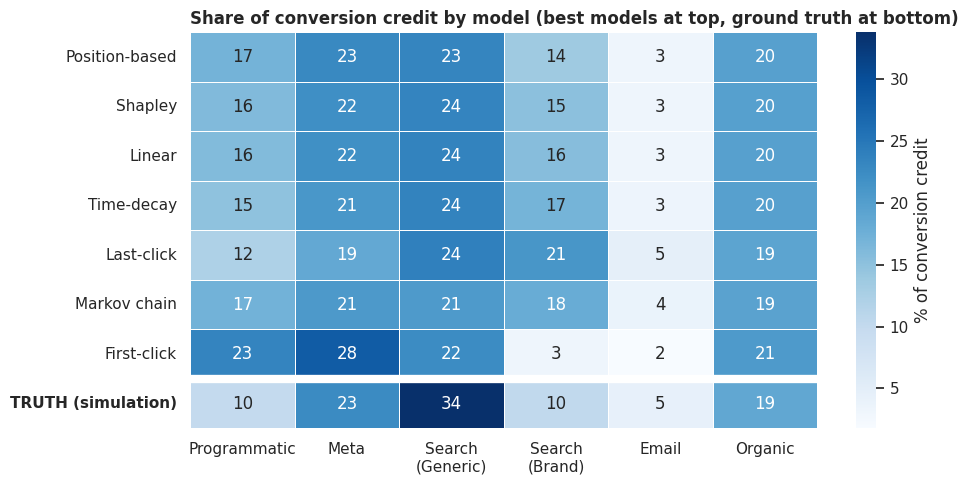

In [12]:
order = summary.index.tolist() + ["TRUTH (simulation)"]
hm = (shares[order].T * 100)
hm.columns = [SHORT[c] for c in hm.columns]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hm, annot=True, fmt=".0f", cmap="Blues", linewidths=.5, linecolor="white",
            cbar_kws={"label": "% of conversion credit"}, ax=ax)
ax.axhline(len(order) - 1, color="white", lw=6)
ax.get_yticklabels()[-1].set_fontweight("bold")
ax.grid(False); ax.set_title("Share of conversion credit by model (best models at top, ground truth at bottom)", fontweight="bold", loc="left")
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(IMG / "04_credit_by_model_heatmap.png", dpi=150); plt.show()

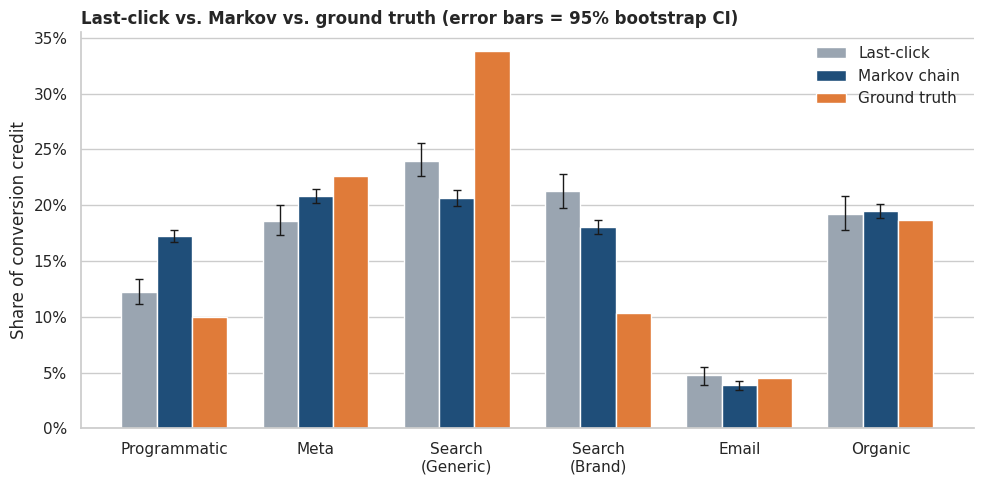

True share falls inside the 95% interval for 0/6 channels with Markov and 2/6 with last-click.


In [13]:
# Last-click vs Markov (95% bootstrap interval) vs ground truth, per channel
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CH)); w_ = 0.25
lc = shares["Last-click"].values; mk = shares["Markov chain"].values; tr = shares["TRUTH (simulation)"].values
ax.bar(x - w_, lc, w_, color=PALETTE["muted"], label="Last-click",
       yerr=[lc - last_ci["lo"].values, last_ci["hi"].values - lc], capsize=3, error_kw={"lw": 1})
ax.bar(x, mk, w_, color=PALETTE["primary"], label="Markov chain",
       yerr=[mk - markov_ci["lo"].values, markov_ci["hi"].values - mk], capsize=3, error_kw={"lw": 1})
ax.bar(x + w_, tr, w_, color=PALETTE["accent"], label="Ground truth")
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CH])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Share of conversion credit")
ax.set_title("Last-click vs. Markov vs. ground truth (error bars = 95% bootstrap CI)", fontweight="bold", loc="left")
ax.legend(frameon=False); sns.despine(); plt.tight_layout()
plt.savefig(IMG / "05_lastclick_vs_markov_vs_truth.png", dpi=150); plt.show()

inside = ((tr >= markov_ci["lo"].values) & (tr <= markov_ci["hi"].values)).sum()
inside_lc = ((tr >= last_ci["lo"].values) & (tr <= last_ci["hi"].values)).sum()
print(f"True share falls inside the 95% interval for {inside}/{len(CH)} channels with Markov and {inside_lc}/{len(CH)} with last-click.")

In [14]:
# What no attribution model can see: baseline demand
total_conv = NC
print(f"Observed conversions: {total_conv:,}")
print(f"Baseline conversions that would have happened WITHOUT any marketing touch (simulation truth): "
      f"{baseline_conv:,.0f} ({baseline_conv / total_conv:.0%})")
print(f"Conversions truly caused by the six channels: {truth_inc.sum():,.0f} (marginal effects, they overlap slightly)")

Observed conversions: 2,669
Baseline conversions that would have happened WITHOUT any marketing touch (simulation truth): 659 (25%)
Conversions truly caused by the six channels: 1,923 (marginal effects, they overlap slightly)


## 7. From credit to budget: ROAS and spend vs. credit

Attributed revenue divided by spend gives a ROAS per model. For Markov and Shapley, credit shares are applied to total revenue.
The *true* incremental ROAS uses the ground-truth incremental conversions x average order value.
Spend for paid channels comes from my [paid-media-budget-optimization](https://github.com/TomasVargas1911/paid-media-budget-optimization)
week-4 mix (scaled to a 3-month window); Email and Organic costs are assumptions.

In [15]:
spend_s = spend.set_index("channel")["spend"].reindex(CH)
total_rev = j["revenue"].sum()
aov = cj["revenue"].mean()

roas = pd.DataFrame(index=CH)
roas["Spend"] = spend_s
roas["Spend share"] = spend_s / spend_s.sum()
roas["ROAS last-click"] = rev_credit["Last-click"] / spend_s
roas["ROAS Markov"] = markov_share * total_rev / spend_s
roas["ROAS Shapley"] = shapley_share * total_rev / spend_s
roas["TRUE incremental ROAS"] = truth_inc * aov / spend_s
roas["Credit share last-click"] = shares["Last-click"]
roas["Credit share Markov"] = shares["Markov chain"]
roas["Credit share TRUTH"] = shares["TRUTH (simulation)"]

fmt = roas.copy()
for c in ["Spend share", "Credit share last-click", "Credit share Markov", "Credit share TRUTH"]:
    fmt[c] = fmt[c].map("{:.0%}".format)
for c in ["ROAS last-click", "ROAS Markov", "ROAS Shapley", "TRUE incremental ROAS"]:
    fmt[c] = fmt[c].map("{:.1f}x".format)
fmt["Spend"] = fmt["Spend"].map("${:,.0f}".format)
print(f"Blended ROAS: {total_rev / spend_s.sum():.1f}x on ${spend_s.sum():,.0f} spend")
fmt

Blended ROAS: 5.8x on $32,100 spend


,Spend,Spend share,ROAS last-click,ROAS Markov,ROAS Shapley,TRUE incremental ROAS,Credit share last-click,Credit share Markov,Credit share TRUTH
Programmatic,"$13,200",41%,1.8x,2.4x,2.3x,1.0x,12%,17%,10%
Meta Ads,"$9,000",28%,3.8x,4.3x,4.6x,3.4x,19%,21%,23%
Google Search (Generic),"$6,000",19%,7.5x,6.4x,7.3x,7.5x,24%,21%,34%
Google Search (Brand),"$1,800",6%,21.6x,18.6x,15.6x,7.7x,21%,18%,10%
Email,$600,2%,14.0x,11.9x,10.1x,10.0x,5%,4%,5%
Organic / SEO,"$1,500",5%,23.7x,24.1x,24.6x,16.6x,19%,19%,19%


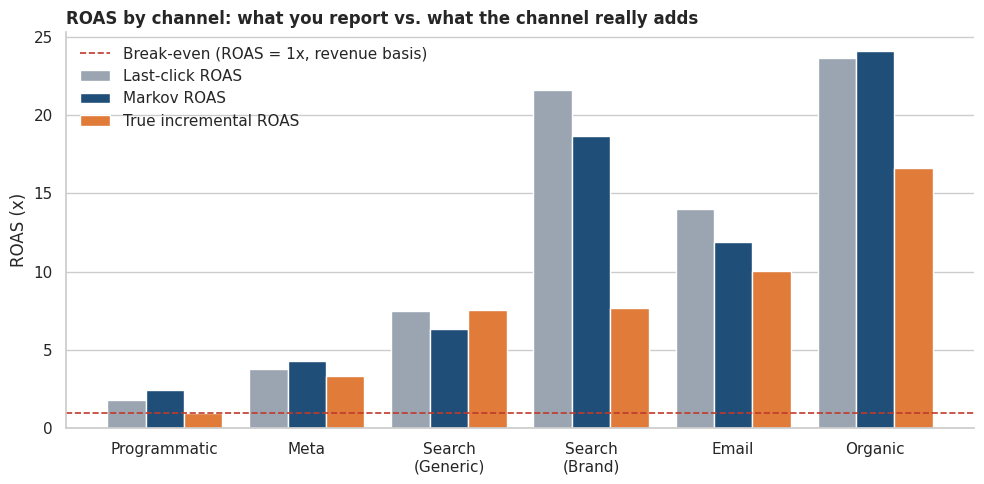

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CH)); w_ = 0.27
ax.bar(x - w_, roas["ROAS last-click"], w_, color=PALETTE["muted"], label="Last-click ROAS")
ax.bar(x, roas["ROAS Markov"], w_, color=PALETTE["primary"], label="Markov ROAS")
ax.bar(x + w_, roas["TRUE incremental ROAS"], w_, color=PALETTE["accent"], label="True incremental ROAS")
ax.axhline(1, color=PALETTE["bad"], ls="--", lw=1.2, label="Break-even (ROAS = 1x, revenue basis)")
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CH]); ax.set_ylabel("ROAS (x)")
ax.set_title("ROAS by channel: what you report vs. what the channel really adds", fontweight="bold", loc="left")
ax.legend(frameon=False); sns.despine(); plt.tight_layout()
plt.savefig(IMG / "06_roas_by_model.png", dpi=150); plt.show()

In [17]:
# Export a channel-level summary
summary_out = pd.DataFrame({
    "spend": spend_s,
    "conversions_last_click": conv_credit["Last-click"],
    "conversions_markov": markov_share * NC,
    "conversions_shapley": shapley_share * NC,
    "conversions_true_incremental": truth_inc,
    "roas_last_click": roas["ROAS last-click"],
    "roas_markov": roas["ROAS Markov"],
    "roas_true_incremental": roas["TRUE incremental ROAS"],
    "markov_share_ci_low": markov_ci["lo"], "markov_share_ci_high": markov_ci["hi"],
})
summary_out.round(3).to_csv(REP / "channel_attribution_summary.csv")
print("Saved reports/channel_attribution_summary.csv")

Saved reports/channel_attribution_summary.csv


## 8. Recommendations

| Channel | What the analysis shows | Suggested action |
|---|---|---|
| **Google Search (Brand)** | 21.6x last-click ROAS vs. 7.7x true incremental ROAS: part of the "performance" is demand that already existed. Mostly a closer (567 last touches vs. 89 first). | Keep it (still profitable), but do **not** scale budget on last-click ROAS. Run a **brand-search holdout** in matched regions for 2-4 weeks to measure the real lift. |
| **Programmatic** | 41% of spend, ~10% of true incremental credit, true ROAS ~1.0x (break-even on revenue, loss after margin). Highest assist ratio (2.1), but assisting is not the same as causing. | Run a **geo-lift test** cutting spend 30-50% in test regions, cap frequency (ad fatigue), and shift budget toward Generic Search and Meta while the test runs. |
| **Google Search (Generic)** | Most under-credited channel (34% true share vs. 21-24% in the models); last-click ROAS is accurate at 7.5x. | Test a budget **increase** and track marginal ROAS; scale until it flattens. |
| **Meta Ads** | Attribution is roughly right (3.4x true vs. 3.8-4.6x reported). | Keep; focus on creative testing. |
| **Email / Organic** | Small spend, very high ROAS (costs are assumptions). Email is capped by the size of the subscriber list. | Grow the list; protect content investment. |

**Measurement plan for a real account**
1. Treat attribution models as **directional** and report credit as a *range* across models, not a single number.
2. Use **incrementality experiments** (geo holdouts, ghost ads, conversion-lift studies) for the channels where models disagree most: Brand Search and Programmatic.
3. Calibrate: when an experiment contradicts the model, adjust the channel's credit and re-run the analysis.
4. Track assist ratios and path length alongside last-click so awareness channels are not judged on closing alone.

## 9. Limitations and next steps
- **Simulated data.** Channel lifts, funnel structure and spend are assumptions, so channel-level conclusions are not benchmarks.
- **Ground truth is model-based.** It is defined by my noisy-OR conversion model with fatigue; real incrementality is also affected by seasonality, pricing and competitors.
- **The data-generating process is a first-order Markov chain**, which should favour the Markov attribution model. Real journeys have longer memory, so a real-data comparison could look different.
- **No identity or cross-device problems, no view-through vs. click distinction**, which are the biggest practical issues in real tracking.
- **Shapley here uses converting journeys only**, a known limitation of the common formulation.
- **Next steps:** higher-order Markov models, a Marketing Mix Model (MMM) to complement user-level attribution, and re-running the pipeline on a public journey dataset.